<a href="https://colab.research.google.com/github/teodoraztodorovic/IPuM/blob/main/IPuM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cost-sensitive logistička regresija na WDBC bazi: uticaj cene greške i grupa obeležja (oblik vs. veličina)

1. **H1**: da li povećanje cene lažno negativnog nalaza (cost-sensitive trening) povećava osetljivost modela za maligne slučajeve bez značajnog pada tačnosti.
2. **H2**: da li obeležja oblika tumora (concavity, concave_points, compactness) bolje razlikuju maligne od benignih tumora nego obeležja veličine (radius, perimeter, area).
3. **H3**: da li model treniran samo na obeležjima oblika (SHAPE) postiže performanse uporedive sa modelom na svih 30 obeležja, i da li je bolji od modela treniranog samo na obeležjima veličine (SIZE).


### Uvoz biblioteka

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              confusion_matrix, roc_auc_score, roc_curve)

import os

plt.rcParams['figure.dpi'] = 100

### Povezivanje sa Google Drive-om

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Konstante projekta

In [ ]:
SEED = 42
COST_FN = 10
W_LIST = [1, 2, 5, 10, 20]

DATA_PATH = '/content/drive/MyDrive/IPuM/wdbc.data'
RESULTS_DIR = '/content/drive/MyDrive/IPuM/rezultati'
os.makedirs(RESULTS_DIR, exist_ok=True)

### Učitavanje i imenovanje kolona

In [ ]:
base_features = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                  'compactness', 'concavity', 'concave_points', 'symmetry',
                  'fractal_dimension']
suffixes = ['mean', 'se', 'worst']
feature_names = [f'{feat}_{suf}' for suf in suffixes for feat in base_features]
column_names = ['id', 'diagnosis'] + feature_names

df = pd.read_csv(DATA_PATH, header=None, names=column_names)
df['y'] = (df['diagnosis'] == 'M').astype(int)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,y
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [ ]:
df['id'].duplicated().any()

np.False_

### Grupe

In [ ]:
size_base = ['radius', 'perimeter', 'area']
SIZE = [f'{feat}_{suf}' for suf in suffixes for feat in size_base]

shape_base = ['concavity', 'concave_points', 'compactness']
SHAPE = [f'{feat}_{suf}' for suf in suffixes for feat in shape_base]

other_base = ['texture', 'smoothness', 'symmetry', 'fractal_dimension']
OTHER = [f'{feat}_{suf}' for suf in suffixes for feat in other_base]

ALL = feature_names

print(f'SIZE ({len(SIZE)}):', SIZE)
print(f'SHAPE ({len(SHAPE)}):', SHAPE)
print(f'OTHER ({len(OTHER)}):', OTHER)
print(f'ALL ({len(ALL)}):', ALL)

SIZE (9): ['radius_mean', 'perimeter_mean', 'area_mean', 'radius_se', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']
SHAPE (9): ['concavity_mean', 'concave_points_mean', 'compactness_mean', 'concavity_se', 'concave_points_se', 'compactness_se', 'concavity_worst', 'concave_points_worst', 'compactness_worst']
OTHER (12): ['texture_mean', 'smoothness_mean', 'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'smoothness_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'smoothness_worst', 'symmetry_worst', 'fractal_dimension_worst']
ALL (30): ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_

### Provera podataka

In [ ]:
print('Oblik tabele:', df.shape)

print('\nRaspodela klasa (diagnosis):')
print(df['diagnosis'].value_counts())

print('\nRaspodela y (1=maligni, 0=benigni):')
print(df['y'].value_counts())

print('\nUkupan broj nedostajućih vrednosti:', df.isna().sum().sum())
print('Broj duplikata ID-a:', df['id'].duplicated().sum())

df[ALL].describe().T

Oblik tabele: (569, 33)

Raspodela klasa (diagnosis):
diagnosis
B    357
M    212
Name: count, dtype: int64

Raspodela y (1=maligni, 0=benigni):
y
0    357
1    212
Name: count, dtype: int64

Ukupan broj nedostajućih vrednosti: 0
Broj duplikata ID-a: 0


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### Priprema matrice obeležja i ciljne promenljive

In [ ]:
X = df[ALL].copy()
y = df['y'].copy()

print('Oblik X:', X.shape)
print('Oblik y:', y.shape)
print('Udeo maligne klase u y:', y.mean().round(4))

Oblik X: (569, 30)
Oblik y: (569,)
Udeo maligne klase u y: 0.3726


## Baseline model

### Jedna stratifikovana 80/20 podela

In [ ]:
def make_pipeline(w=1):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=1.0,
            max_iter=10000,
            random_state=SEED,
            class_weight={0: 1, 1: w}
        ))
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print('Trening skup:', X_train.shape, '| Test skup:', X_test.shape)
print('Broj M/B u treningu:', y_train.value_counts().to_dict())
print('Broj M/B u testu:', y_test.value_counts().to_dict())

pipe = make_pipeline(w=1)
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print(f'\nTačnost: {acc:.4f}')
print(f'Recall (M): {rec:.4f}')
print(f'Specifičnost (B): {specificity:.4f}')
print(f'Preciznost (M): {prec:.4f}')
print(f'ROC-AUC: {auc:.4f}')
print(f'\nMatrica konfuzije: TP={tp}, FN={fn}, FP={fp}, TN={tn}')

baseline_single = pd.DataFrame([{
    'accuracy': acc, 'recall_M': rec, 'specificity_B': specificity,
    'precision_M': prec, 'roc_auc': auc,
    'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn
}])
baseline_single.to_csv(f'{RESULTS_DIR}/korak1_baseline_single_split.csv', index=False)
baseline_single

Trening skup: (455, 30) | Test skup: (114, 30)
Broj M/B u treningu: {0: 285, 1: 170}
Broj M/B u testu: {0: 72, 1: 42}

Tačnost: 0.9649
Recall (M): 0.9286
Specifičnost (B): 0.9861
Preciznost (M): 0.9750
ROC-AUC: 0.9960

Matrica konfuzije: TP=39, FN=3, FP=1, TN=71


,accuracy,recall_M,specificity_B,precision_M,roc_auc,TP,FN,FP,TN
0,0.964912,0.928571,0.986111,0.975,0.996032,39,3,1,71


### Ponavljanje na 100 različitih podela

Srednja tačnost: 0.9761
Standardna devijacija: 0.0143
Minimum: 0.9298
Maksimum: 1.0000


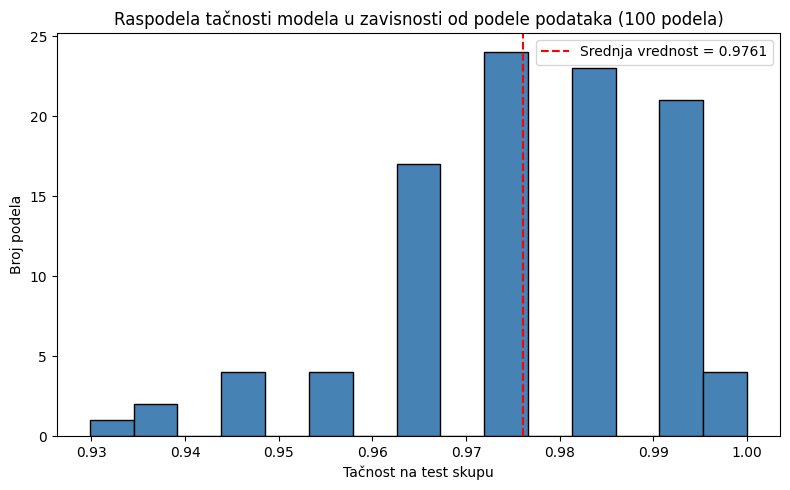

In [ ]:
n_repeats = 100
accuracies = []

for seed in range(n_repeats):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    p = make_pipeline(w=1)
    p.fit(X_tr, y_tr)
    acc_i = accuracy_score(y_te, p.predict(X_te))
    accuracies.append(acc_i)

accuracies = np.array(accuracies)

print(f'Srednja tačnost: {accuracies.mean():.4f}')
print(f'Standardna devijacija: {accuracies.std(ddof=1):.4f}')
print(f'Minimum: {accuracies.min():.4f}')
print(f'Maksimum: {accuracies.max():.4f}')

acc_summary = pd.DataFrame([{
    'mean_accuracy': accuracies.mean(),
    'std_accuracy': accuracies.std(ddof=1),
    'min_accuracy': accuracies.min(),
    'max_accuracy': accuracies.max(),
    'n_repeats': n_repeats
}])
acc_summary.to_csv(f'{RESULTS_DIR}/korak1_baseline_100seeds_summary.csv', index=False)

plt.figure(figsize=(8, 5))
plt.hist(accuracies, bins=15, color='steelblue', edgecolor='black')
plt.axvline(accuracies.mean(), color='red', linestyle='--',
            label=f'Srednja vrednost = {accuracies.mean():.4f}')
plt.title('Raspodela tačnosti modela u zavisnosti od podele podataka (100 podela)')
plt.xlabel('Tačnost na test skupu')
plt.ylabel('Broj podela')
plt.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/korak1_histogram_tacnost_100seeds.png', dpi=200)
plt.show()

## Evaluacija

### Fiksna lista podela (50 foldova)

In [ ]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
cv_splits = list(rskf.split(X, y))

print(f'Ukupan broj foldova: {len(cv_splits)}')

tr_idx, te_idx = cv_splits[0]
print(f'Primer fold-a 0: trening={len(tr_idx)}, test={len(te_idx)}')
print(f'Odnos test/trening: {len(te_idx)/len(tr_idx):.4f}')

Ukupan broj foldova: 50
Primer fold-a 0: trening=455, test=114
Odnos test/trening: 0.2505


### Funkcija evaluate()

In [ ]:
def sensitivity_at_specificity(y_true, y_proba, target_specificity=0.95):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    target_fpr = 1 - target_specificity
    sens = np.interp(target_fpr, fpr, tpr)
    return sens


def evaluate(feature_cols, w, cv_splits=cv_splits, X=X, y=y, cost_fn=COST_FN):
    rows = []
    X_sub = X[feature_cols]

    for fold_i, (train_idx, test_idx) in enumerate(cv_splits):
        X_tr, X_te = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        pipe = make_pipeline(w=w)
        pipe.fit(X_tr, y_tr)

        y_pred = pipe.predict(X_te)
        y_proba = pipe.predict_proba(X_te)[:, 1]

        tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0, 1]).ravel()

        acc = accuracy_score(y_te, y_pred)
        rec = recall_score(y_te, y_pred, zero_division=0)
        prec = precision_score(y_te, y_pred, zero_division=0)
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        auc = roc_auc_score(y_te, y_proba)
        cost = (cost_fn * fn + fp) / len(y_te)
        sens95 = sensitivity_at_specificity(y_te, y_proba, 0.95)

        rows.append({
            'fold': fold_i, 'w': w,
            'accuracy': acc, 'recall_M': rec, 'specificity_B': spec,
            'precision_M': prec, 'roc_auc': auc, 'cost': cost,
            'sens_at_spec95': sens95,
            'TP': tp, 'FN': fn, 'FP': fp, 'TN': tn,
            'n_test': len(y_te)
        })

    return pd.DataFrame(rows)

### Provera funkcije na svim obeležjima

In [ ]:
results_all_w1 = evaluate(ALL, w=1)

print('Broj redova (očekujemo 50):', len(results_all_w1))
print('\nSrednje vrednosti ± SD po metrikama:\n')

metrics_cols = ['accuracy', 'recall_M', 'specificity_B', 'precision_M',
                 'roc_auc', 'cost', 'sens_at_spec95']

summary = results_all_w1[metrics_cols].agg(['mean', 'std']).T
summary.columns = ['mean', 'std']
print(summary.round(4))

results_all_w1.to_csv(f'{RESULTS_DIR}/korak2_test_ALL_w1_folds.csv', index=False)
summary.to_csv(f'{RESULTS_DIR}/korak2_test_ALL_w1_summary.csv')

Broj redova (očekujemo 50): 50

Srednje vrednosti ± SD po metrikama:

                  mean     std
accuracy        0.9789  0.0143
recall_M        0.9576  0.0339
specificity_B   0.9916  0.0089
precision_M     0.9856  0.0153
roc_auc         0.9948  0.0054
cost            0.1634  0.1274
sens_at_spec95  0.9726  0.0215


##H1: uticaj cene lažno negativnog nalaza

### Treniranje modela za različite težine

In [ ]:
results_by_w = {}

for w in W_LIST:
    print(f'Treniranje modela za w={w}...')
    results_by_w[w] = evaluate(ALL, w=w)

print('\nGotovo. Broj modela (težina):', len(results_by_w))

Treniranje modela za w=1...
Treniranje modela za w=2...
Treniranje modela za w=5...
Treniranje modela za w=10...
Treniranje modela za w=20...

Gotovo. Broj modela (težina): 5


### Tabela rezultata po težinama

In [ ]:
summary_rows = []

for w in W_LIST:
    df_w = results_by_w[w]
    summary_rows.append({
        'w': w,
        'recall_M_mean': df_w['recall_M'].mean(),
        'recall_M_std': df_w['recall_M'].std(),
        'specificity_B_mean': df_w['specificity_B'].mean(),
        'specificity_B_std': df_w['specificity_B'].std(),
        'accuracy_mean': df_w['accuracy'].mean(),
        'accuracy_std': df_w['accuracy'].std(),
        'cost_mean': df_w['cost'].mean(),
        'cost_std': df_w['cost'].std(),
    })

h1_summary = pd.DataFrame(summary_rows)
h1_summary.to_csv(f'{RESULTS_DIR}/korak3_h1_summary_po_w.csv', index=False)
print(h1_summary.round(4).to_string(index=False))

 w  recall_M_mean  recall_M_std  specificity_B_mean  specificity_B_std  accuracy_mean  accuracy_std  cost_mean  cost_std
 1         0.9576        0.0339              0.9916             0.0089         0.9789        0.0143     0.1634    0.1274
 2         0.9656        0.0253              0.9742             0.0175         0.9710        0.0124     0.1444    0.0920
 5         0.9707        0.0222              0.9521             0.0261         0.9591        0.0151     0.1390    0.0773
10         0.9717        0.0224              0.9260             0.0362         0.9431        0.0204     0.1518    0.0759
20         0.9736        0.0222              0.9047             0.0422         0.9304        0.0247     0.1581    0.0771


### Grafik recall-a i specifičnosti u zavisnosti od w

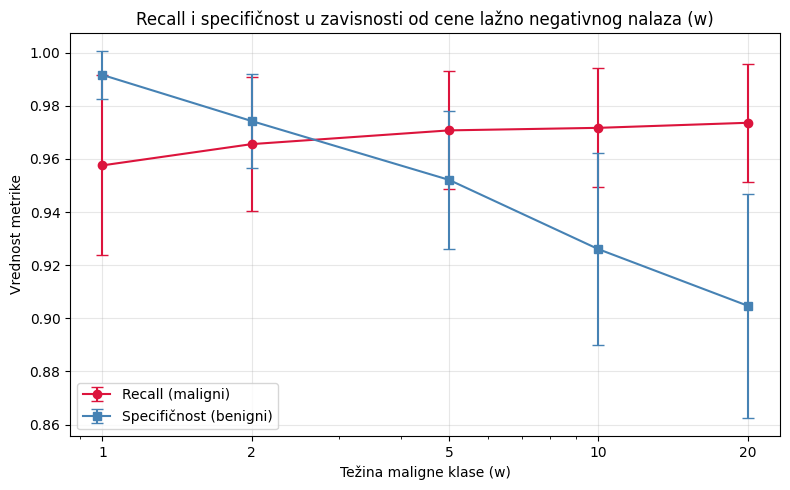

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(h1_summary['w'], h1_summary['recall_M_mean'],
            yerr=h1_summary['recall_M_std'], marker='o', capsize=4,
            label='Recall (maligni)', color='crimson')
ax.errorbar(h1_summary['w'], h1_summary['specificity_B_mean'],
            yerr=h1_summary['specificity_B_std'], marker='s', capsize=4,
            label='Specifičnost (benigni)', color='steelblue')

ax.set_xscale('log')
ax.set_xticks(W_LIST)
ax.set_xticklabels(W_LIST)
ax.set_xlabel('Težina maligne klase (w)')
ax.set_ylabel('Vrednost metrike')
ax.set_title('Recall i specifičnost u zavisnosti od cene lažno negativnog nalaza (w)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/korak3_recall_specificity_vs_w.png', dpi=200)
plt.show()

### Statistička značajnost razlika

In [ ]:
def nadeau_bengio_ci(diffs, k=50, train_test_ratio=1/4, alpha=0.05):
    n = len(diffs)
    mean_d = np.mean(diffs)
    var_d = np.var(diffs, ddof=1)

    corrected_var = (1/n + train_test_ratio) * var_d
    se_corrected = np.sqrt(corrected_var)

    t_stat = mean_d / se_corrected if se_corrected > 0 else np.nan
    df = n - 1
    t_crit = stats.t.ppf(1 - alpha/2, df)

    ci_low = mean_d - t_crit * se_corrected
    ci_high = mean_d + t_crit * se_corrected
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df))

    return mean_d, ci_low, ci_high, t_stat, p_value


baseline_w1 = results_by_w[1]

comparison_rows = []
for w in W_LIST:
    if w == 1:
        continue
    df_w = results_by_w[w]

    for metric in ['recall_M', 'accuracy']:
        diffs = (df_w[metric] - baseline_w1[metric]).values
        mean_d, ci_low, ci_high, t_stat, p_val = nadeau_bengio_ci(diffs)
        comparison_rows.append({
            'w': w, 'metric': metric,
            'mean_diff': mean_d, 'ci_low': ci_low, 'ci_high': ci_high,
            't_stat': t_stat, 'p_value': p_val
        })

h1_comparisons = pd.DataFrame(comparison_rows)
h1_comparisons.to_csv(f'{RESULTS_DIR}/korak3_h1_uparene_razlike_vs_w1.csv', index=False)
print(h1_comparisons.round(4).to_string(index=False))

 w   metric  mean_diff  ci_low  ci_high  t_stat  p_value
 2 recall_M     0.0080 -0.0066   0.0226  1.1024   0.2757
 2 accuracy    -0.0079 -0.0187   0.0029 -1.4638   0.1496
 5 recall_M     0.0132 -0.0117   0.0380  1.0659   0.2917
 5 accuracy    -0.0199 -0.0394  -0.0004 -2.0458   0.0462
10 recall_M     0.0141 -0.0116   0.0399  1.1020   0.2759
10 accuracy    -0.0358 -0.0624  -0.0093 -2.7099   0.0092
20 recall_M     0.0160 -0.0109   0.0430  1.1957   0.2376
20 accuracy    -0.0485 -0.0793  -0.0177 -3.1633   0.0027


### Provera kriterijuma pada tačnosti

In [ ]:
acc_diffs = h1_comparisons[h1_comparisons['metric'] == 'accuracy'].copy()
acc_diffs['pad_manji_od_1pp'] = acc_diffs['ci_low'] > -0.01
print(acc_diffs[['w', 'mean_diff', 'ci_low', 'ci_high', 'pad_manji_od_1pp']].round(4).to_string(index=False))

 w  mean_diff  ci_low  ci_high  pad_manji_od_1pp
 2    -0.0079 -0.0187   0.0029             False
 5    -0.0199 -0.0394  -0.0004             False
10    -0.0358 -0.0624  -0.0093             False
20    -0.0485 -0.0793  -0.0177             False


##H2: diskriminativna moć pojedinačnih obeležja

### AUC svakog obeležja sa bootstrap intervalima poverenja

In [ ]:
def auc_with_bootstrap_ci(y_true, feature_values, n_boot=1000, seed=SEED):
    y_true = np.asarray(y_true)
    feature_values = np.asarray(feature_values)

    auc_raw = roc_auc_score(y_true, feature_values)
    auc_point = max(auc_raw, 1 - auc_raw)

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]

    rng = np.random.RandomState(seed)
    boot_aucs = []

    for _ in range(n_boot):
        sample_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
        sample_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
        sample_idx = np.concatenate([sample_pos, sample_neg])

        y_sample = y_true[sample_idx]
        f_sample = feature_values[sample_idx]

        if len(np.unique(y_sample)) < 2:
            continue

        auc_b = roc_auc_score(y_sample, f_sample)
        boot_aucs.append(max(auc_b, 1 - auc_b))

    ci_low = np.percentile(boot_aucs, 2.5)
    ci_high = np.percentile(boot_aucs, 97.5)

    return auc_point, ci_low, ci_high


def get_group(feature_name):
    if feature_name in SIZE:
        return 'SIZE'
    elif feature_name in SHAPE:
        return 'SHAPE'
    else:
        return 'OTHER'


auc_rows = []
for feat in ALL:
    auc_point, ci_low, ci_high = auc_with_bootstrap_ci(y.values, X[feat].values)
    auc_rows.append({
        'feature': feat,
        'group': get_group(feat),
        'auc': auc_point,
        'ci_low': ci_low,
        'ci_high': ci_high
    })

auc_table = pd.DataFrame(auc_rows).sort_values('auc', ascending=False).reset_index(drop=True)
auc_table.to_csv(f'{RESULTS_DIR}/korak4_auc_pojedinacna_obelezja.csv', index=False)
print(auc_table.round(4).to_string(index=False))

                feature group    auc  ci_low  ci_high
        perimeter_worst  SIZE 0.9755  0.9636   0.9850
           radius_worst  SIZE 0.9704  0.9572   0.9813
             area_worst  SIZE 0.9698  0.9559   0.9809
   concave_points_worst SHAPE 0.9667  0.9504   0.9801
    concave_points_mean SHAPE 0.9644  0.9493   0.9767
         perimeter_mean  SIZE 0.9469  0.9267   0.9630
              area_mean  SIZE 0.9383  0.9165   0.9563
         concavity_mean SHAPE 0.9378  0.9180   0.9570
            radius_mean  SIZE 0.9375  0.9155   0.9554
                area_se  SIZE 0.9264  0.9025   0.9465
        concavity_worst SHAPE 0.9214  0.8988   0.9432
           perimeter_se  SIZE 0.8764  0.8467   0.9031
              radius_se  SIZE 0.8683  0.8367   0.8981
       compactness_mean SHAPE 0.8638  0.8328   0.8916
      compactness_worst SHAPE 0.8623  0.8316   0.8912
      concave_points_se SHAPE 0.7918  0.7551   0.8256
          texture_worst OTHER 0.7846  0.7477   0.8232
           concavity_se SHAP

### Grafik AUC-a po obeležju

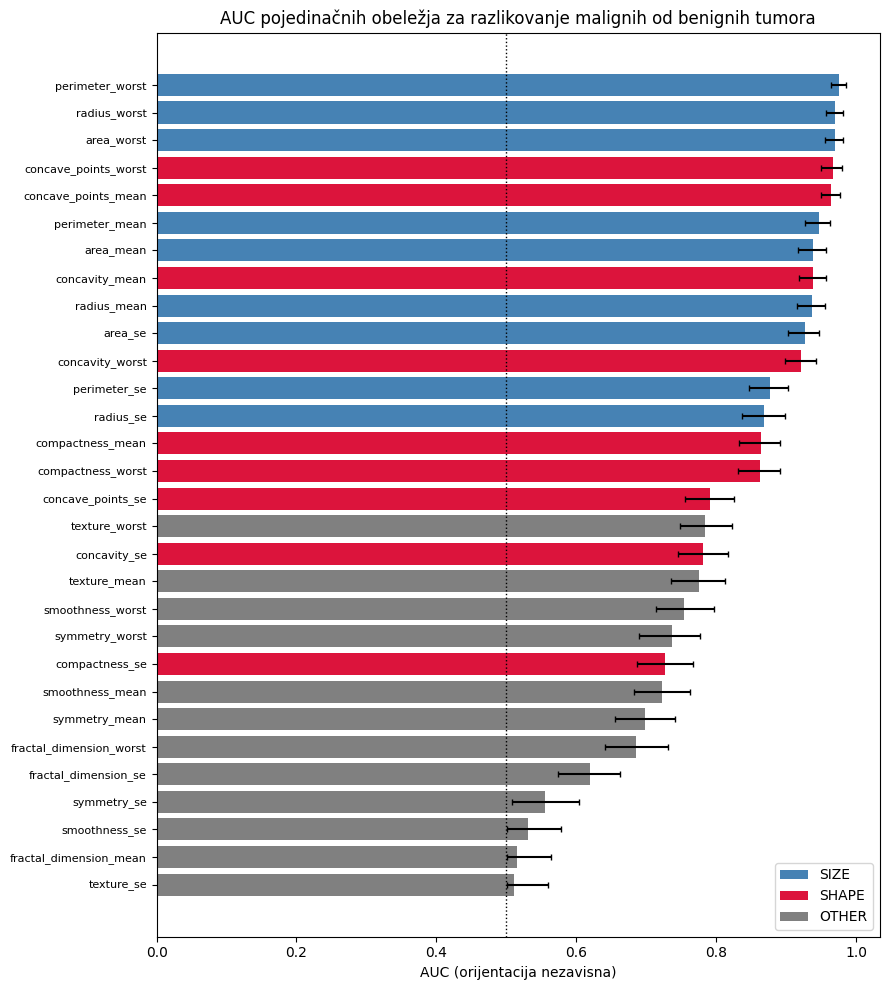

In [ ]:
from matplotlib.patches import Patch

color_map = {'SIZE': 'steelblue', 'SHAPE': 'crimson', 'OTHER': 'gray'}
colors = auc_table['group'].map(color_map)

fig, ax = plt.subplots(figsize=(9, 10))
y_pos = np.arange(len(auc_table))

ax.barh(y_pos, auc_table['auc'], color=colors,
        xerr=[auc_table['auc'] - auc_table['ci_low'], auc_table['ci_high'] - auc_table['auc']],
        capsize=2)
ax.set_yticks(y_pos)
ax.set_yticklabels(auc_table['feature'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('AUC (orijentacija nezavisna)')
ax.set_title('AUC pojedinačnih obeležja za razlikovanje malignih od benignih tumora')
ax.axvline(0.5, color='black', linestyle=':', linewidth=1)

legend_elements = [Patch(facecolor=color_map[g], label=g) for g in color_map]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/korak4_bar_auc_po_obelezju.png', dpi=200)
plt.show()

### Uparena poređenja SHAPE i SIZE obeležja

In [ ]:
def paired_auc_diff_bootstrap(y_true, feat_a_values, feat_b_values, n_boot=1000, seed=SEED):
    y_true = np.asarray(y_true)
    feat_a_values = np.asarray(feat_a_values)
    feat_b_values = np.asarray(feat_b_values)
    n = len(y_true)

    def signed_auc(y, f):
        raw = roc_auc_score(y, f)
        return raw if raw >= 0.5 else 1 - raw

    auc_a_point = signed_auc(y_true, feat_a_values)
    auc_b_point = signed_auc(y_true, feat_b_values)
    diff_point = auc_a_point - auc_b_point

    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]

    rng = np.random.RandomState(seed)
    boot_diffs = []

    for _ in range(n_boot):
        sample_pos = rng.choice(idx_pos, size=len(idx_pos), replace=True)
        sample_neg = rng.choice(idx_neg, size=len(idx_neg), replace=True)
        sample_idx = np.concatenate([sample_pos, sample_neg])

        y_s = y_true[sample_idx]
        if len(np.unique(y_s)) < 2:
            continue

        a_s = feat_a_values[sample_idx]
        b_s = feat_b_values[sample_idx]

        auc_a_b = signed_auc(y_s, a_s)
        auc_b_b = signed_auc(y_s, b_s)
        boot_diffs.append(auc_a_b - auc_b_b)

    ci_low = np.percentile(boot_diffs, 2.5)
    ci_high = np.percentile(boot_diffs, 97.5)

    return diff_point, ci_low, ci_high


pairs = [
    ('concave_points_mean', 'perimeter_mean'),
    ('concave_points_se', 'perimeter_se'),
    ('concave_points_worst', 'perimeter_worst'),
    ('concavity_mean', 'area_mean'),
    ('concavity_se', 'area_se'),
    ('concavity_worst', 'area_worst'),
    ('compactness_mean', 'radius_mean'),
    ('compactness_se', 'radius_se'),
    ('compactness_worst', 'radius_worst'),
]

pair_rows = []
for shape_feat, size_feat in pairs:
    diff, ci_low, ci_high = paired_auc_diff_bootstrap(
        y.values, X[shape_feat].values, X[size_feat].values
    )
    pair_rows.append({
        'shape_feature': shape_feat,
        'size_feature': size_feat,
        'auc_diff_shape_minus_size': diff,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'shape_znacajno_bolji': ci_low > 0,
        'size_znacajno_bolji': ci_high < 0
    })

h2_pairs = pd.DataFrame(pair_rows)
h2_pairs.to_csv(f'{RESULTS_DIR}/korak4_h2_uparena_poredjenja.csv', index=False)
print(h2_pairs.round(4).to_string(index=False))

       shape_feature    size_feature  auc_diff_shape_minus_size  ci_low  ci_high  shape_znacajno_bolji  size_znacajno_bolji
 concave_points_mean  perimeter_mean                     0.0175 -0.0010   0.0384                 False                False
   concave_points_se    perimeter_se                    -0.0846 -0.1155  -0.0536                 False                 True
concave_points_worst perimeter_worst                    -0.0087 -0.0234   0.0060                 False                False
      concavity_mean       area_mean                    -0.0005 -0.0265   0.0281                 False                False
        concavity_se         area_se                    -0.1456 -0.1844  -0.1097                 False                 True
     concavity_worst      area_worst                    -0.0485 -0.0721  -0.0237                 False                 True
    compactness_mean     radius_mean                    -0.0737 -0.1077  -0.0361                 False                 True
      co

### Korelaciona analiza SIZE i SHAPE grupa

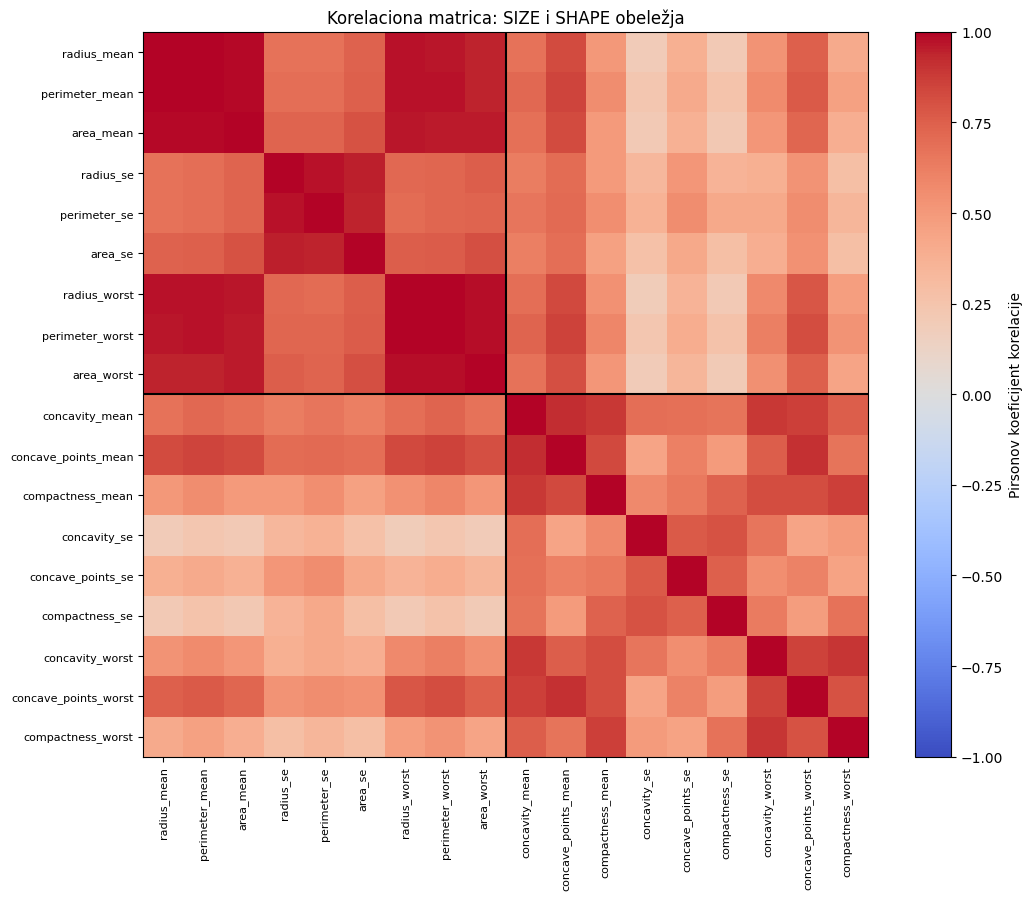

Prosečna apsolutna korelacija unutar SIZE grupe: 0.8492
Prosečna apsolutna korelacija unutar SHAPE grupe: 0.7046


In [ ]:
size_shape_features = SIZE + SHAPE
corr_matrix = X[size_shape_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(size_shape_features)))
ax.set_yticks(range(len(size_shape_features)))
ax.set_xticklabels(size_shape_features, rotation=90, fontsize=8)
ax.set_yticklabels(size_shape_features, fontsize=8)

ax.axhline(len(SIZE) - 0.5, color='black', linewidth=1.5)
ax.axvline(len(SIZE) - 0.5, color='black', linewidth=1.5)

ax.set_title('Korelaciona matrica: SIZE i SHAPE obeležja')
fig.colorbar(im, ax=ax, label='Pirsonov koeficijent korelacije')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/korak4_heatmap_korelacija_size_shape.png', dpi=200)
plt.show()

size_only_corr = X[SIZE].corr()
mask = ~np.eye(len(SIZE), dtype=bool)
print(f'Prosečna apsolutna korelacija unutar SIZE grupe: {np.abs(size_only_corr.values[mask]).mean():.4f}')

shape_only_corr = X[SHAPE].corr()
mask_shape = ~np.eye(len(SHAPE), dtype=bool)
print(f'Prosečna apsolutna korelacija unutar SHAPE grupe: {np.abs(shape_only_corr.values[mask_shape]).mean():.4f}')

##H3: SIZE vs SHAPE vs ALL

### Evaluacija tri grupe obeležja

In [ ]:
groups = {'SIZE': SIZE, 'SHAPE': SHAPE, 'ALL': ALL}
weights_h3 = [1, 10]

results_h3 = {}
for gname, gcols in groups.items():
    for w in weights_h3:
        key = (gname, w)
        print(f'Treniranje: grupa={gname}, w={w}...')
        if gname == 'ALL' and w in results_by_w:
            results_h3[key] = results_by_w[w]
        else:
            results_h3[key] = evaluate(gcols, w=w)

print('\nGotovo. Broj kombinacija:', len(results_h3))

Treniranje: grupa=SIZE, w=1...
Treniranje: grupa=SIZE, w=10...
Treniranje: grupa=SHAPE, w=1...
Treniranje: grupa=SHAPE, w=10...
Treniranje: grupa=ALL, w=1...
Treniranje: grupa=ALL, w=10...

Gotovo. Broj kombinacija: 6


### Tabela rezultata po grupama

In [ ]:
metrics_h3 = ['recall_M', 'specificity_B', 'accuracy', 'roc_auc', 'cost', 'sens_at_spec95']

summary_h3_rows = []
for (gname, w), df_res in results_h3.items():
    row = {'group': gname, 'w': w}
    for m in metrics_h3:
        row[f'{m}_mean'] = df_res[m].mean()
        row[f'{m}_std'] = df_res[m].std()
    summary_h3_rows.append(row)

h3_summary = pd.DataFrame(summary_h3_rows).sort_values(['group', 'w']).reset_index(drop=True)
h3_summary.to_csv(f'{RESULTS_DIR}/korak5_h3_summary.csv', index=False)

display_cols = ['group', 'w'] + [c for m in metrics_h3 for c in (f'{m}_mean', f'{m}_std')]
print(h3_summary[display_cols].round(4).to_string(index=False))

group  w  recall_M_mean  recall_M_std  specificity_B_mean  specificity_B_std  accuracy_mean  accuracy_std  roc_auc_mean  roc_auc_std  cost_mean  cost_std  sens_at_spec95_mean  sens_at_spec95_std
  ALL  1         0.9576        0.0339              0.9916             0.0089         0.9789        0.0143        0.9948       0.0054     0.1634    0.1274               0.9726              0.0215
  ALL 10         0.9717        0.0224              0.9260             0.0362         0.9431        0.0204        0.9902       0.0090     0.1518    0.0759               0.9674              0.0277
SHAPE  1         0.8811        0.0472              0.9605             0.0213         0.9309        0.0224        0.9774       0.0139     0.4678    0.1770               0.9066              0.0524
SHAPE 10         0.9627        0.0311              0.8039             0.0408         0.8631        0.0289        0.9769       0.0149     0.2620    0.1206               0.9037              0.0589
 SIZE  1         0.8750  

### Uparena poređenja SHAPE-ALL i SHAPE-SIZE

In [ ]:
shape_w10 = results_h3[('SHAPE', 10)]
all_w10 = results_h3[('ALL', 10)]
size_w10 = results_h3[('SIZE', 10)]

h3_comparisons = []
for metric in ['sens_at_spec95', 'cost']:
    diffs_shape_all = (shape_w10[metric] - all_w10[metric]).values
    mean_d, ci_low, ci_high, t_stat, p_val = nadeau_bengio_ci(diffs_shape_all)
    h3_comparisons.append({
        'comparison': 'SHAPE - ALL', 'metric': metric,
        'mean_diff': mean_d, 'ci_low': ci_low, 'ci_high': ci_high, 'p_value': p_val
    })

    diffs_shape_size = (shape_w10[metric] - size_w10[metric]).values
    mean_d2, ci_low2, ci_high2, t_stat2, p_val2 = nadeau_bengio_ci(diffs_shape_size)
    h3_comparisons.append({
        'comparison': 'SHAPE - SIZE', 'metric': metric,
        'mean_diff': mean_d2, 'ci_low': ci_low2, 'ci_high': ci_high2, 'p_value': p_val2
    })

h3_comp_df = pd.DataFrame(h3_comparisons)
h3_comp_df.to_csv(f'{RESULTS_DIR}/korak5_h3_uparene_razlike.csv', index=False)
print(h3_comp_df.round(4).to_string(index=False))

  comparison         metric  mean_diff  ci_low  ci_high  p_value
 SHAPE - ALL sens_at_spec95    -0.0637 -0.1180  -0.0094   0.0224
SHAPE - SIZE sens_at_spec95    -0.0047 -0.0785   0.0690   0.8980
 SHAPE - ALL           cost     0.1102  0.0049   0.2154   0.0406
SHAPE - SIZE           cost     0.0442 -0.1076   0.1960   0.5612


### Test neinferiornosti

In [ ]:
non_inferiority = h3_comp_df[
    (h3_comp_df['comparison'] == 'SHAPE - ALL') &
    (h3_comp_df['metric'] == 'sens_at_spec95')
].copy()

non_inferiority['neinferiornost_potvrdjena'] = non_inferiority['ci_low'] > -0.01
print(non_inferiority[['comparison', 'metric', 'mean_diff', 'ci_low', 'ci_high',
                         'neinferiornost_potvrdjena']].round(4).to_string(index=False))

 comparison         metric  mean_diff  ci_low  ci_high  neinferiornost_potvrdjena
SHAPE - ALL sens_at_spec95    -0.0637  -0.118  -0.0094                      False


### Usrednjene ROC krive

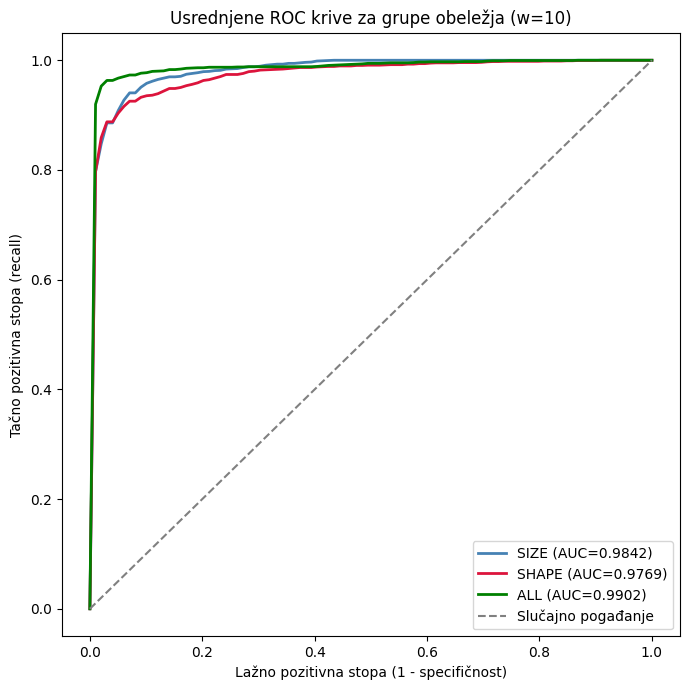

In [ ]:
def mean_roc_curve(feature_cols, w, cv_splits=cv_splits, n_points=100):
    mean_fpr = np.linspace(0, 1, n_points)
    tprs = []

    X_sub = X[feature_cols]
    for train_idx, test_idx in cv_splits:
        X_tr, X_te = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        pipe = make_pipeline(w=w)
        pipe.fit(X_tr, y_tr)
        y_proba = pipe.predict_proba(X_te)[:, 1]

        fpr, tpr, _ = roc_curve(y_te, y_proba)
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tpr_interp[0] = 0.0
        tprs.append(tpr_interp)

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0

    return mean_fpr, mean_tpr


fig, ax = plt.subplots(figsize=(7, 7))
colors_groups = {'SIZE': 'steelblue', 'SHAPE': 'crimson', 'ALL': 'green'}

for gname, gcols in groups.items():
    mean_fpr, mean_tpr = mean_roc_curve(gcols, w=10)
    auc_mean = results_h3[(gname, 10)]['roc_auc'].mean()
    ax.plot(mean_fpr, mean_tpr, label=f'{gname} (AUC={auc_mean:.4f})',
            color=colors_groups[gname], linewidth=2)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Slučajno pogađanje')
ax.set_xlabel('Lažno pozitivna stopa (1 - specifičnost)')
ax.set_ylabel('Tačno pozitivna stopa (recall)')
ax.set_title('Usrednjene ROC krive za grupe obeležja (w=10)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/korak5_roc_krive_grupe.png', dpi=200)
plt.show()